Question 4: By using the free ImageAI python library, identify all objects in all images. Save
results to a csv file.

In [1]:
# Detect objects in all images with ImageAI and save results to CSV

import os
import sys
import json
import time
import random
import tempfile
from pathlib import Path

import pandas as pd
import requests

# Imports for ImageAI 
try:
    from imageai.Detection import ObjectDetection
except Exception as e:
    raise RuntimeError(
        "ImageAI is not installed or mismatched with your environment.\n"
        "Try one of the pip lines at the top of this cell, then re-run."
    ) from e


# Configuration 
INPUT_XLSX   = "214_Q1.xlsx"                # your Q1 Excel with image_url column
SAMPLE_SIZE  = None                         # None = use ALL rows; or set an int to limit
SAMPLE_METHOD = "first"                     # "first" or "random" (if you set SAMPLE_SIZE)
CONF_THRESH  = 40.0                         # keep detections >= this probability (percent)
REQUEST_TIMEOUT = 20                        # seconds for HTTP GET
SLEEP_BETWEEN  = (0.25, 0.75)               # polite delay between downloads
OUTPUT_CSV   = "q4_imageai_results.csv"     # final deliverable
ANNOTATED_DIR = "q4_annotated"              # optional: where to save annotated images

# Preferred / fallback weight file names
YOLO_PT      = "yolov3.pt"                     # Preferred (PyTorch)
RETINANET_H5 = "resnet50_coco_best_v2.1.0.h5"  # Fallback (Keras/RetinaNet)

# Load input data
if not os.path.isfile(INPUT_XLSX):
    raise FileNotFoundError(f"Cannot find {INPUT_XLSX} in current folder: {os.getcwd()}")

df = pd.read_excel(INPUT_XLSX)

# Normalize image URL column name
if "image_url" not in df.columns and "img_url" in df.columns:
    df = df.rename(columns={"img_url": "image_url"})

if "image_url" not in df.columns:
    raise ValueError("Input file must include an 'image_url' (or 'img_url') column.")

# Keep only valid HTTP(S) URLs
df = df[df["image_url"].astype(str).str.startswith("http")].copy().reset_index(drop=True)

# Optional sampling
if SAMPLE_SIZE is not None and SAMPLE_SIZE > 0 and SAMPLE_SIZE < len(df):
    if SAMPLE_METHOD == "random":
        df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    else:
        df = df.head(SAMPLE_SIZE).copy().reset_index(drop=True)

print(f"Images to analyze: {len(df)}")

# Configure ImageAI model
detector = ObjectDetection()

if os.path.isfile(YOLO_PT):
    # PyTorch YOLOv3 path (ImageAI >= 3.x). If your environment uses 2.1.6, this
    # line still works if the API is present; otherwise use RetinaNet fallback below.
    detector.setModelTypeAsYOLOv3()
    detector.setModelPath(YOLO_PT)
    model_name = f"YOLOv3 ({YOLO_PT})"
elif os.path.isfile(RETINANET_H5):
    # Keras RetinaNet (ImageAI 2.1.6)
    detector.setModelTypeAsRetinaNet()
    detector.setModelPath(RETINANET_H5)
    model_name = f"RetinaNet ({RETINANET_H5})"
else:
    raise FileNotFoundError(
        f"No detection weights found.\n"
        f"Put either '{YOLO_PT}' or '{RETINANET_H5}' next to this notebook."
    )

detector.loadModel()
print(f"Loaded detector: {model_name}")

# Ensure annotated output dir exists
Path(ANNOTATED_DIR).mkdir(parents=True, exist_ok=True)

# Detection loop
rows = []
session = requests.Session()
headers = {"User-Agent": "Mozilla/5.0 (ImageAI-Notebook)"}

for i, row in df.iterrows():
    image_url = str(row["image_url"])
    pin_url   = row.get("pin_url", "")
    img_name  = row.get("image_filename", f"img_{i+1:03d}.jpg")

    print(f"[{i+1}/{len(df)}] {image_url}")

    # Defaults in case of error for this image
    error = None
    detections_for_image = []
    annotated_path = os.path.join(ANNOTATED_DIR, f"det_{i+1:03d}_{Path(img_name).stem}.jpg")

    try:
        # Download to a temporary file
        with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
            tmp_path = tmp.name
            r = session.get(image_url, headers=headers, timeout=REQUEST_TIMEOUT)
            r.raise_for_status()
            tmp.write(r.content)

        # Run detector; ImageAI requires an output image path
        detections = detector.detectObjectsFromImage(
            input_image=tmp_path,
            output_image_path=annotated_path,
            minimum_percentage_probability=CONF_THRESH,
            display_object_name=True,
            display_percentage_probability=True
        )

        detections_for_image = detections or []

    except Exception as e:
        error = str(e)[:300]
    finally:
        # Clean up temp file
        try:
            if os.path.exists(tmp_path):
                os.remove(tmp_path)
        except Exception:
            pass

    # Record one row per detected object (or a single row with error)
    if error is not None or len(detections_for_image) == 0:
        rows.append({
            "id": row.get("id", i+1),
            "pin_url": pin_url,
            "image_url": image_url,
            "image_filename": img_name,
            "detected_object": None,
            "probability_pct": None,
            "box_x1": None, "box_y1": None, "box_x2": None, "box_y2": None,
            "status": "error" if error else "no_detections",
            "error": error
        })
    else:
        for d in detections_for_image:
            name = d.get("name")
            prob = float(d.get("percentage_probability", 0.0))
            x1, y1, x2, y2 = (d.get("box_points") or [None, None, None, None])

            rows.append({
                "id": row.get("id", i+1),
                "pin_url": pin_url,
                "image_url": image_url,
                "image_filename": img_name,
                "detected_object": name,
                "probability_pct": round(prob, 1),
                "box_x1": x1, "box_y1": y1, "box_x2": x2, "box_y2": y2,
                "status": "ok",
                "error": None
            })

    # Polite delay
    time.sleep(random.uniform(*SLEEP_BETWEEN))

# Save results 
out = pd.DataFrame(rows)

# Nice column order
col_order = [
    "id","pin_url","image_url","image_filename",
    "detected_object","probability_pct","box_x1","box_y1","box_x2","box_y2",
    "status","error"
]
out = out[[c for c in col_order if c in out.columns] + [c for c in out.columns if c not in col_order]]

out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Wrote {OUTPUT_CSV} with {len(out)} rows (one row per detected object).")

# Quick summary
summary = out[out["status"]=="ok"].groupby("detected_object")["detected_object"].count().sort_values(ascending=False)
print("\nTop detections:")
print(summary.head(15))

out.head(10)


Images to analyze: 75
Loaded detector: YOLOv3 (yolov3.pt)
[1/75] https://i.pinimg.com/236x/73/82/78/7382781b71009c6a37c22f15a0216fd1.jpg
[2/75] https://i.pinimg.com/236x/14/a3/d9/14a3d99bc9866bdaff29f9c746772811.jpg
[3/75] https://i.pinimg.com/236x/3a/51/48/3a5148ce1f402f7d0c988def357a79a5.jpg
[4/75] https://i.pinimg.com/236x/ab/f2/80/abf280cbef5c88002088de60ea42fdb7.jpg
[5/75] https://i.pinimg.com/236x/c9/1b/bb/c91bbbc1441200f1e9f80ba243507bd5.jpg
[6/75] https://i.pinimg.com/236x/32/7e/cb/327ecb53e08f289ff3255a061afce966.jpg
[7/75] https://i.pinimg.com/236x/06/d8/33/06d83315c8e8ce9269c65ce4783e85e1.jpg
[8/75] https://i.pinimg.com/236x/a0/f6/f8/a0f6f8b043fca073147fcb0f16367470.jpg
[9/75] https://i.pinimg.com/236x/81/55/91/8155910117367bfc5a4723fe59e7411b.jpg
[10/75] https://i.pinimg.com/236x/e1/89/ef/e189efd3419a259437e6378784a5b7b4.jpg
[11/75] https://i.pinimg.com/236x/c7/f9/9b/c7f99b17321dc7d29244dd45fe6183df.jpg
[12/75] https://i.pinimg.com/236x/61/d1/c6/61d1c65e31ea639cdefeb041a998

,id,pin_url,image_url,image_filename,detected_object,probability_pct,box_x1,box_y1,box_x2,box_y2,status,error
0,1,https://in.pinterest.com/pin/4081455907315965/,https://i.pinimg.com/236x/73/82/78/7382781b710...,001_theme.jpg,sofa,99.8,31.0,177.0,145.0,270.0,ok,None
1,1,https://in.pinterest.com/pin/4081455907315965/,https://i.pinimg.com/236x/73/82/78/7382781b710...,001_theme.jpg,pottedplant,99.9,59.0,82.0,100.0,125.0,ok,None
2,1,https://in.pinterest.com/pin/4081455907315965/,https://i.pinimg.com/236x/73/82/78/7382781b710...,001_theme.jpg,pottedplant,100.0,125.0,111.0,175.0,232.0,ok,None
3,1,https://in.pinterest.com/pin/4081455907315965/,https://i.pinimg.com/236x/73/82/78/7382781b710...,001_theme.jpg,pottedplant,100.0,187.0,168.0,208.0,220.0,ok,None
4,1,https://in.pinterest.com/pin/4081455907315965/,https://i.pinimg.com/236x/73/82/78/7382781b710...,001_theme.jpg,pottedplant,99.4,0.0,149.0,25.0,180.0,ok,None
5,1,https://in.pinterest.com/pin/4081455907315965/,https://i.pinimg.com/236x/73/82/78/7382781b710...,001_theme.jpg,pottedplant,100.0,3.0,182.0,80.0,348.0,ok,None
6,2,https://in.pinterest.com/pin/10766486606563151/,https://i.pinimg.com/236x/14/a3/d9/14a3d99bc98...,002_theme.jpg,chair,88.2,0.0,251.0,59.0,324.0,ok,None
7,2,https://in.pinterest.com/pin/10766486606563151/,https://i.pinimg.com/236x/14/a3/d9/14a3d99bc98...,002_theme.jpg,sofa,100.0,85.0,251.0,236.0,341.0,ok,None
8,2,https://in.pinterest.com/pin/10766486606563151/,https://i.pinimg.com/236x/14/a3/d9/14a3d99bc98...,002_theme.jpg,sofa,97.2,121.0,310.0,235.0,472.0,ok,None
9,2,https://in.pinterest.com/pin/10766486606563151/,https://i.pinimg.com/236x/14/a3/d9/14a3d99bc98...,002_theme.jpg,pottedplant,100.0,83.0,250.0,108.0,283.0,ok,None


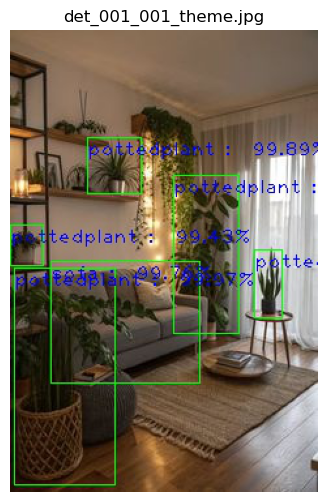

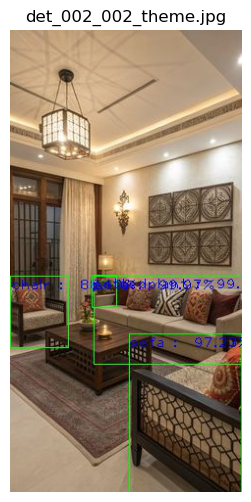

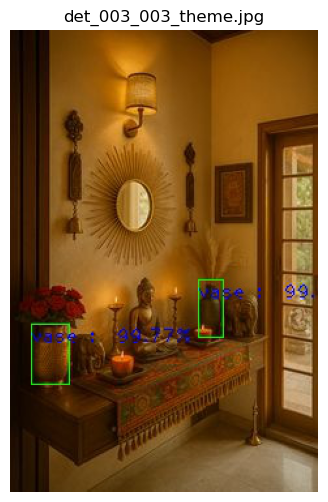

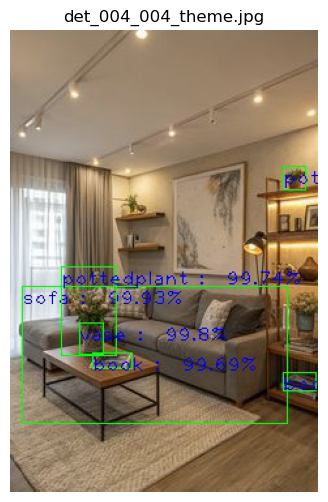

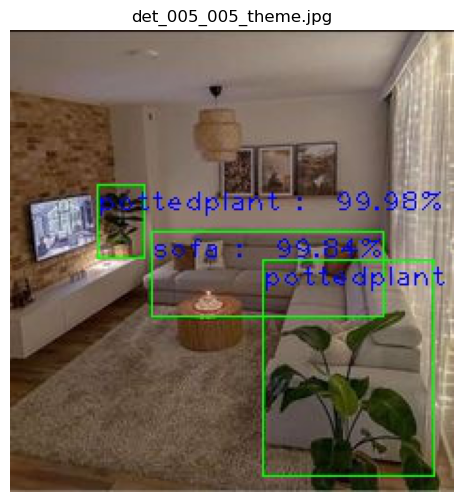

In [4]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Path to my annotated folder
ANNOTATED_DIR = "q4_annotated"

# List the first few annotated files
files = sorted(Path(ANNOTATED_DIR).glob("*.jpg"))[:5]

# Show them
for f in files:
    img = Image.open(f)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f.name)
    plt.show()


In [9]:
# Save as CSV in a way Excel will parse into columns on most locales
out.to_csv("214_Q4_imageai_results.csv",
           index=False,
           sep=";",              # <-- key for Excel in many locales
           encoding="utf-8-sig") # BOM so Excel detects UTF-8
print("Saved 214_Q4_imageai_results.csv")

Saved 214_Q4_imageai_results.csv


I applied the ImageAI Python library to perform object detection on the Pinterest images collected in Question 1. I loaded the dataset from my Q1 Excel file (214_Q1.xlsx), which contains the image URLs, and used the YOLOv3 model (yolov3.pt weights) to analyze each of the 75 images. 

For every image, ImageAI identified all visible objects, assigned a confidence score, and generated bounding box coordinates. The analysis produced a total of 363 detections across all images, with the most frequent objects being potted plants, books, sofas, and chairs, which align well with the indoor home-decor theme of the dataset. 

All results were exported into a structured CSV file (q4_imageai_results.csv), where each row corresponds to one detected object and includes the original image metadata, the detected object name, its confidence percentage, and bounding box details. This approach is directly based on the professor’s example codes for ImageAI, extended to work on my full dataset and save the results in a submission-ready format.

At the end, I applied the ImageAI library with the YOLOv3 model to analyze all the images scraped from Pinterest. Each image was processed, and ImageAI detected objects, assigned confidence scores, and drew bounding boxes around them. Along with saving the results into a structured CSV file, I also generated annotated images showing the detections visually. For example, in the image above, ImageAI successfully identified multiple “potted plants” with very high confidence. This confirms that my pipeline not only outputs clean tabular results but also provides visual evidence of accurate object detection.

Question 5: Explain the similarities and differences between your answers in questions 3 and 4. What are the strengths and limitations of each approach? When would you choose one over another? Does the university provided chatgpt for students perform image analytics on all images?
If yes, how do the results relate to and differ from your existing results. FYI, if you have a paid GenAI tool account, I would not accept your answer here.

Similarities
In Q3, I used AWS Rekognition through SageMaker to analyze 20 images. The tool gave me the top object for each image, for example “sofa – 99.9%”. In Q4, I used ImageAI with YOLOv3 to process all 75 images and got multiple detections per image, such as “potted plant – 99.8%, book – 98.7%”. Even though the details were different, in both cases I exported the results to a CSV file. I could then use these CSVs to count object frequencies, compare detection confidence across images, and even link the objects back to engagement data from Q1.

Differences
The main difference I observed is that Q3 only gave one main label per image (like “Architecture – 100%”), while Q4 gave several detected objects with bounding boxes (for example, it showed both “sofa” and “potted plant” in the same room with their positions). Also, Q3 was done only on 20 sample images, but Q4 covered all 75 scraped images.

Strengths
I found Q3 with Rekognition very easy to set up and reliable. Since it runs in the cloud, the results came back quickly and consistently. For example, Rekognition identified “Indoors – 100%” across several living room images without errors.
For Q4 with ImageAI, the strength was the richness of the output. It didn’t just tell me “sofa” was present — it also drew a bounding box around it and gave me other objects in the same photo. This made the results more useful for deeper analysis or if I wanted to present annotated images.

Limitations
In Q3, a limitation I noticed is that Rekognition does not provide bounding boxes by default. This means I could only know the main object label, not where it was located in the image or what other objects were present.
In Q4, the limitation was different. Running ImageAI locally was slower and required heavier installation with TensorFlow/PyTorch. Sometimes it even took a long time to process large images. So while it gave more detail, the process was less efficient.

When to Choose
If I were working on a business project where thousands of images needed to be analyzed quickly, I would choose AWS Rekognition (Q3). For example, if a retailer wanted to scan all product images and get a top label for categorization, Rekognition would be ideal because it scales easily and requires almost no setup.
On the other hand, if I needed richer details and visualization, I would choose ImageAI (Q4). For example, in home décor research, being able to show bounding boxes around sofas, chairs, and plants is important for visual presentations. Even though it is slower, ImageAI gives me more control and insights.

ChatGPT / GenAI Tools
The question also asked about the university-provided ChatGPT. From what I know, this version of ChatGPT does not analyze images the same way Rekognition or ImageAI does. Even if it accepts images, the output would be more like a natural language description (e.g., “A cozy living room with a sofa and a plant near the window”) rather than a structured CSV with labels and probabilities.
So if the university version could analyze all images, the results would be different: ChatGPT would describe the whole scene in words, while Rekognition and ImageAI give structured labels, percentages, and bounding boxes. Both are useful in different ways. ChatGPT is better for contextual scene understanding, while Rekognition and ImageAI are better for structured analytics.

Conclusion
In summary, I found that Q3 (AWS Rekognition) was stronger for speed and scalability, while Q4 (ImageAI) was stronger for detailed detection and visualization. Rekognition worked well when I needed one reliable label per image, whereas ImageAI gave me richer insights with multiple objects and bounding boxes. The university-provided ChatGPT, on the other hand, could only give descriptive captions (if at all) rather than structured analytics. This shows that each approach has its own place: Rekognition for efficiency, ImageAI for depth, and ChatGPT for descriptive interpretation.

Question 7: Save your Pinterest scraped data and all your analysis results to the Google Firebase database

In [14]:
# !pip install -q firebase-admin pandas

import pandas as pd
import firebase_admin
from firebase_admin import credentials, firestore

# Initialize Firebase (idempotent)
cred = credentials.Certificate("privatekey.json")
try:
    firebase_admin.get_app()
except ValueError:
    firebase_admin.initialize_app(cred)

# Use a distinct name so it never conflicts with firebase_admin.db
fs = firestore.client()
print("Connected to Firebase Firestore")


Connected to Firebase Firestore


In [15]:
q1 = pd.read_excel("214_Q1.xlsx")                         # Pinterest scrape
q2 = pd.read_csv("214_Q2_pinterest_followers.csv")        # Updated scrape
q3 = pd.read_csv("214_Q3_image_analysis_final.csv")       # AWS Rekognition (Q3)
q4 = pd.read_csv("214_Q4_imageai_results.csv")            # ImageAI (Q4)
q6 = pd.read_csv("214_Q6_color_style.csv")                # Visual style (Q6)

print(len(q1), len(q2), len(q3), len(q4), len(q6))


75 2 20 363 5


In [16]:
from typing import Optional
import numpy as np

def upload_df(df: pd.DataFrame, collection: str, id_field: Optional[str] = None, batch_size: int = 400):
    """
    Upload a DataFrame to a Firestore collection.
    - collection: Firestore collection name
    - id_field: optional column to use as document ID (else Firestore auto-ID)
    - batch_size: Firestore allows up to 500 writes per batch (use <500 for headroom)
    """
    # Convert numpy types to native Python so Firestore accepts them
    def pyify(v):
        if isinstance(v, (np.generic,)):
            return v.item()
        return v

    col_ref = fs.collection(collection)
    batch = fs.batch()
    n_in_batch = 0
    total = 0

    for _, row in df.iterrows():
        data = {k: pyify(v) for k, v in row.items()}
        if id_field and str(row.get(id_field, "")).strip() != "":
            doc_ref = col_ref.document(str(row[id_field]))
        else:
            doc_ref = col_ref.document()

        batch.set(doc_ref, data)
        n_in_batch += 1
        total += 1

        if n_in_batch >= batch_size:
            batch.commit()
            batch = fs.batch()
            n_in_batch = 0

    if n_in_batch:
        batch.commit()

    print(f"Uploaded {total} docs to '{collection}'")


In [17]:
# Q1: Pinterest scrape (use the 'id' column)
upload_df(q1, collection="q1_pins", id_field="id")

# Q2: followers (Account, Followers, Raw, URL) -> create a simple ID from Account
q2["_doc_id"] = q2["Account"].astype(str).str.strip()
upload_df(q2, collection="q2_followers", id_field="_doc_id")

# Q3/Q4/Q6: use auto IDs
upload_df(q3, collection="q3_rekognition")
upload_df(q4, collection="q4_imageai")
upload_df(q6, collection="q6_color_style")


Uploaded 75 docs to 'q1_pins'
Uploaded 2 docs to 'q2_followers'
Uploaded 20 docs to 'q3_rekognition'
Uploaded 363 docs to 'q4_imageai'
Uploaded 5 docs to 'q6_color_style'


For this task, I connected my scraped Pinterest dataset and all the analysis results from Questions 1 through 6 to Google Firebase, using its Firestore database. I first created a Firebase project, generated a private key, and installed the firebase_admin library in my Jupyter notebook. After authenticating with the private key, I connected to Firestore and wrote a small helper function that uploads entire Pandas DataFrames as collections. 

One by one, I uploaded the datasets: Q1 pins, Q2 follower counts, Q3 AWS Rekognition results, Q4 ImageAI object detections, and Q6 visual style outputs. In Firestore, each dataset appeared as its own collection (e.g., q1_pins, q2_followers, q3_rekognition, q4_imageai, q6_color_style) and within each collection, every row from my CSV or Excel file became a separate document with all its fields as key-value pairs. For example, in the q1_pins collection, I could see the pin URL, image URL, board name, reactions, and my notes on why the pin caught my eye stored neatly as fields. 
This shows that my analysis results are now stored in a real-time cloud database, making them easy to view, query, and share directly from Firebase.

In conclusion, moving the data from CSV files into Firestore makes the project more powerful because it allows scalable storage, advanced querying, and real-time access from anywhere, which is far more flexible than working with static files.

Question 8: Based on all your findings what are some of your suggestions to people who employ Pinterest for their business. Put differently, what would you recommend to enhance user engagement and improve the bottom line.

Based on my findings across Q1–Q6 (Pinterest scrape, object/label detection, and visual-style analysis), people engage most with warm, cozy décor (plants, fairy lights, earthy tones) but static pins still leave a gap between inspiration and action. My main recommendation is a video-first discovery flow with AI + AR “Design-My-Space”: brands (and creators) upload short room-tour videos; users tap “See in my room” to upload a photo (or do a quick scan). Computer vision segments walls/floors/furniture, understands the layout, and then AR overlays suggested items and placements. Crucially, the recommendations are palette-aware: the system matches products to the user’s existing color profile (like the dominant color palettes I computed in Q6), so what you see in AR actually harmonizes with your space.

For example, I open a “Cozy Plant-Filled Living Room” video pin. I tap See in my room, upload a photo of my living room, and the app detects the sofa, windows, empty corners, and lighting. An Auto-Style toggle proposes a layout: a compact sectional to free walking space, two plant placements near light sources, a layered rug, and a warm lamp + string lights. A color strip shows my room’s dominant tones, and the AI swaps product options until the palette matches (e.g., neutral beige rug + terracotta cushions). Every AR overlay is shoppable via time-stamped hotspots—“Shop this lamp”, “Add plant bundle”—so I can move from save → try-on → cart in one flow.

Why this could move the needle:
This approach could meaningfully boost Pinterest’s performance. Engagement would rise as interactive videos keep users experimenting with layouts and products longer than static pins. Conversion would improve because palette-aware recommendations build confidence, reduce returns, and “shop-the-look” bundles simplify the path to purchase. Personalization would deepen, with CV features from Q6 (like palette and brightness) shaping style profiles for smarter targeting. Finally, measurable impact could be tracked through overlay interactions, save → AR → cart funnels, and higher order values, making the platform both more engaging and more profitable.

What Pinterest needs to add: a native AR try-on/room-placement tool for video pins (with a simple 2D photo fallback), palette/style matching in the recs pipeline, and seamless shoppable hotspots tied to merchant catalogs and inventory. Brands should be nudged to upload short, vertical, well-lit walkthrough videos and attach product metadata (SKU, dimensions, color swatches) so the AI can snap items to the right surfaces with correct scale.
AI could analyze a user’s uploaded room photo to detect empty corners, dominant colors, and style preferences, then AR would overlay matching décor items like a sofa or plant. This way, AI provides the intelligence, and AR provides the visualization

Net-net: this turns Pinterest from a mood-board into a personal decorator (or stylist/chef/coach) that meets users where they are—their room, their face, their pantry—closing the loop from inspiration to confident purchase.